Predicting car prices based on features like brand, horsepower, mileage, and body type. We'll train a machine learning model to estimate car prices using a dataset of various car specifications.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Data cleann- Check null values
print(df.isnull().sum())


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [ ]:
#Feature Engineering
df['brand'] = df['Car_Name'].apply(lambda x: x.split()[0])
df.drop(['Car_Name'], axis=1, inplace=True)

In [ ]:
#converting categorical var to numerical using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [ ]:
#Train-Test Split
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Train Model
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#Prediction
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [ ]:
#Evaluation
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Linear Regression Performance:
MAE: 1.2210512082865184
RMSE: 1.8599440262239342
R2 Score: 0.8498240069558907

Random Forest Performance:
MAE: 0.5990590163934425
RMSE: 0.883520234768792
R2 Score: 0.9661129499640729


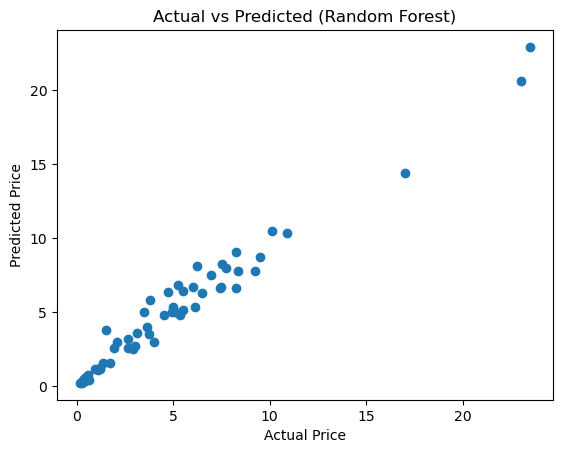

In [ ]:
#visualizations
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()


Top Important Features:
                    Feature  Importance
1             Present_Price    0.869418
0                      Year    0.058472
2                Driven_kms    0.029673
7       Transmission_Manual    0.008916
41               brand_land    0.006860
34           brand_fortuner    0.005954
26               brand_city    0.003394
6   Selling_type_Individual    0.003291
39             brand_innova    0.003270
5          Fuel_Type_Petrol    0.002734


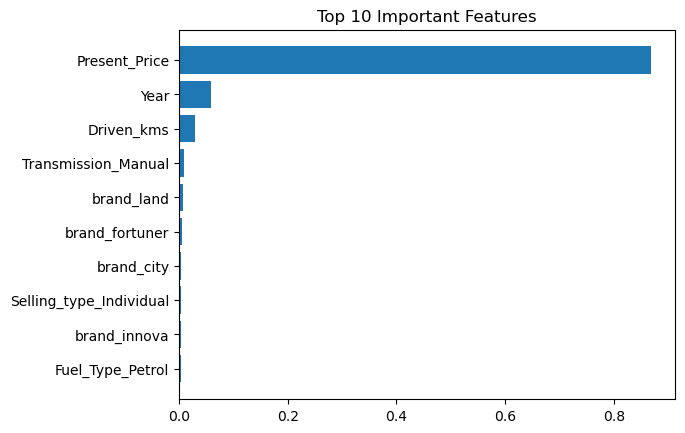

In [ ]:
features = X.columns
importances = rf.feature_importances_

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Important Features:")
print(feature_df.head(10))

# Plot Important Features
plt.figure()
plt.barh(feature_df['Feature'][:10], feature_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [37]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': rf_pred,
})

comparison['Error'] = comparison['Actual Price'] - comparison['Predicted Price']

print(comparison.head(10))


   Actual Price  Predicted Price   Error
0          0.35           0.4379 -0.0879
1         10.11          10.5095 -0.3995
2          4.95           4.9895 -0.0395
3          0.15           0.2119 -0.0619
4          6.95           7.5013 -0.5513
5          7.45           6.6950  0.7550
6          1.10           1.1274 -0.0274
7          0.50           0.5834 -0.0834
8          0.45           0.4675 -0.0175
9          6.00           6.7175 -0.7175


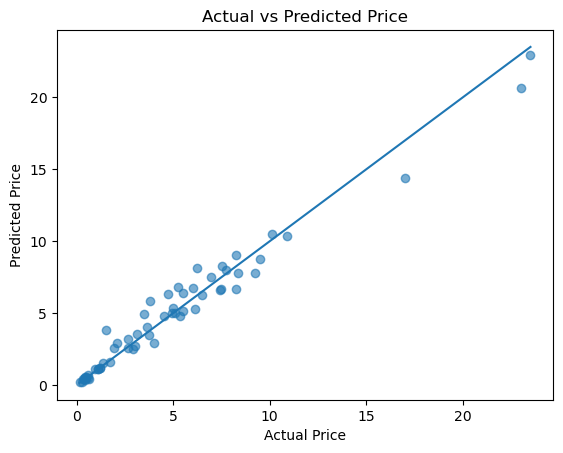

In [34]:
plt.figure()

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()